# Video Game Analytics QA Notebook

This notebook answers the EDA questions with code, comments, and graphs using the merged dataset.

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load data
data_path = os.path.join("..", "data", "processed", "merged_data.csv")
df = pd.read_csv(data_path)

# Parse numbers if needed
def parse_number(s):
    if isinstance(s, str):
        if 'K' in s:
            return float(s.replace('K', '')) * 1000
        else:
            return float(s)
    return s

df['Wishlist'] = df['Wishlist'].apply(parse_number)

## 📁 games.csv (Game Metadata Only)

### 🌟 What are the top-rated games by user reviews?

In [2]:
# Top-rated games by Rating
top_rated = df[['Title', 'Rating']].sort_values('Rating', ascending=False).head(10)
print(top_rated)

                               Title  Rating
913  Metal Gear Solid 3: Subsistence     4.6
54                    Chrono Trigger     4.5
10                        Bloodborne     4.5
120  Metal Gear Solid 3: Snake Eater     4.5
704                       Bloodborne     4.5
730                    Silent Hill 2     4.5
94                          Mother 3     4.5
756                   Chrono Trigger     4.5
393  Metal Gear Solid 3: Snake Eater     4.5
757                   Chrono Trigger     4.5


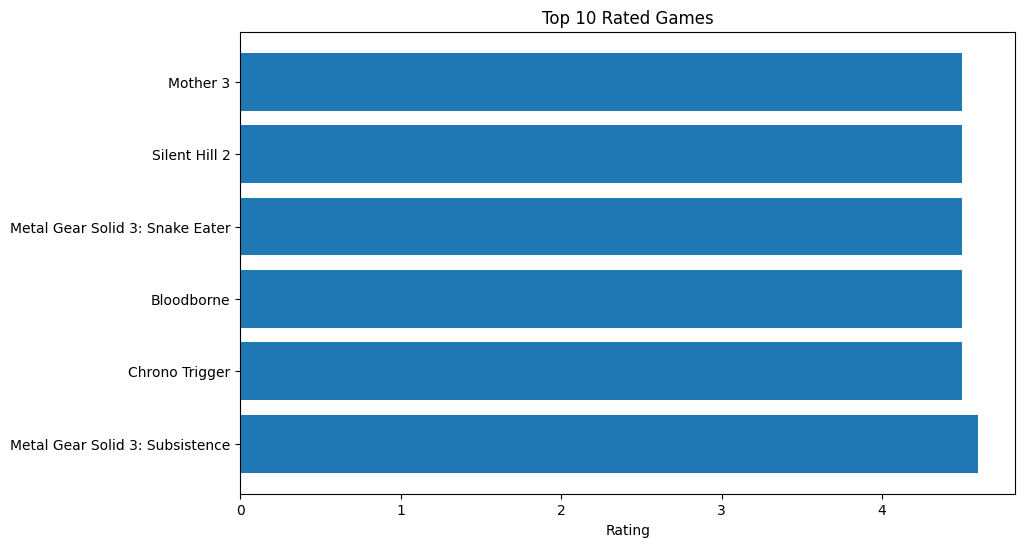

In [3]:
# Bar plot for top ratings
plt.figure(figsize=(10, 6))
plt.barh(top_rated['Title'], top_rated['Rating'])
plt.xlabel('Rating')
plt.title('Top 10 Rated Games')
plt.show()

### 🧑‍🤝‍🧑 Which developers (Teams) have the highest average ratings?

In [4]:
# Average rating by Team
avg_rating_team = df.groupby('Team')['Rating'].mean().sort_values(ascending=False).head(10)
print(avg_rating_team)

Team
['FromSoftware', 'Sony Computer Entertainment']             4.500000
['Konami Computer Entertainment Japan', 'Konami']           4.500000
['Team Silent', 'Konami']                                   4.500000
['Aspyr Media', 'Ion Storm']                                4.400000
['Valve', 'Electronic Arts']                                4.400000
['Sony Computer Entertainment, Inc. (SCEI)', 'Team Ico']    4.400000
['Konami', 'Konami Computer Entertainment Tokyo']           4.400000
['Square']                                                  4.366667
['Square', 'Square Electronic Arts']                        4.300000
['BioWare', 'Electronic Arts']                              4.300000
Name: Rating, dtype: float64


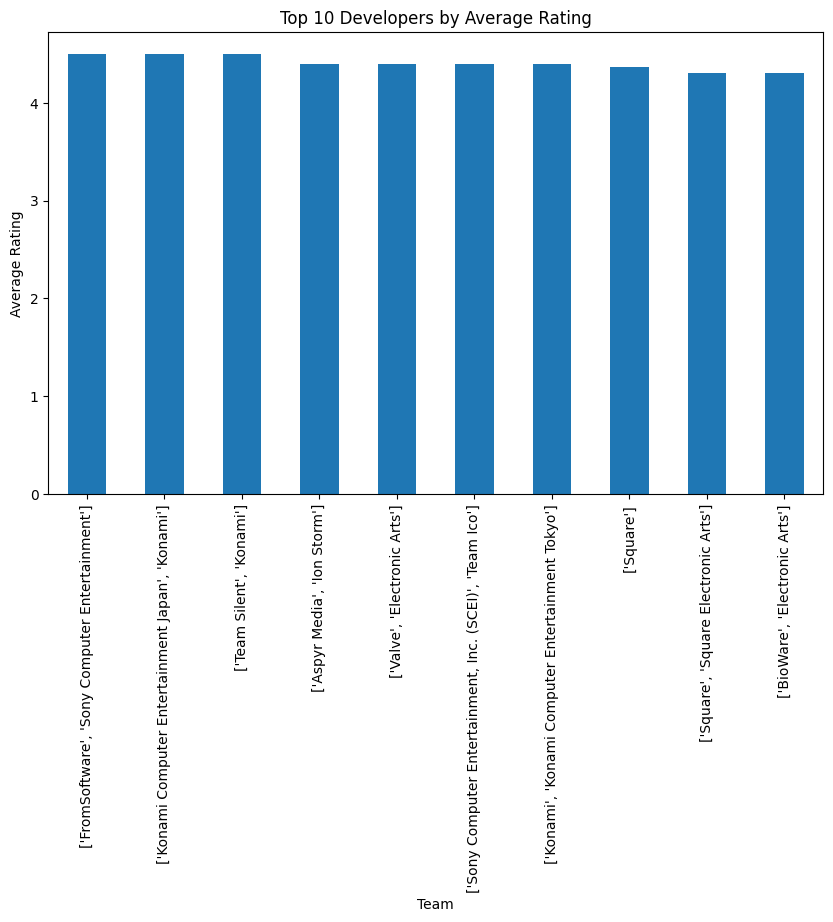

In [5]:
# Bar plot
plt.figure(figsize=(10, 6))
avg_rating_team.plot(kind='bar')
plt.ylabel('Average Rating')
plt.title('Top 10 Developers by Average Rating')
plt.show()

### 🧩 What are the most common genres in the dataset?

In [6]:
# Most common genres
genre_counts = df['Genres'].value_counts().head(10)
print(genre_counts)

Genres
['adventure', 'rpg']               147
['shooter']                        136
['adventure', 'platform']          120
['adventure', 'shooter']           103
['adventure', 'brawler']            55
['rpg', 'shooter']                  49
['platform']                        45
['adventure', 'rpg', 'shooter']     38
['rpg']                             36
['adventure']                       34
Name: count, dtype: int64


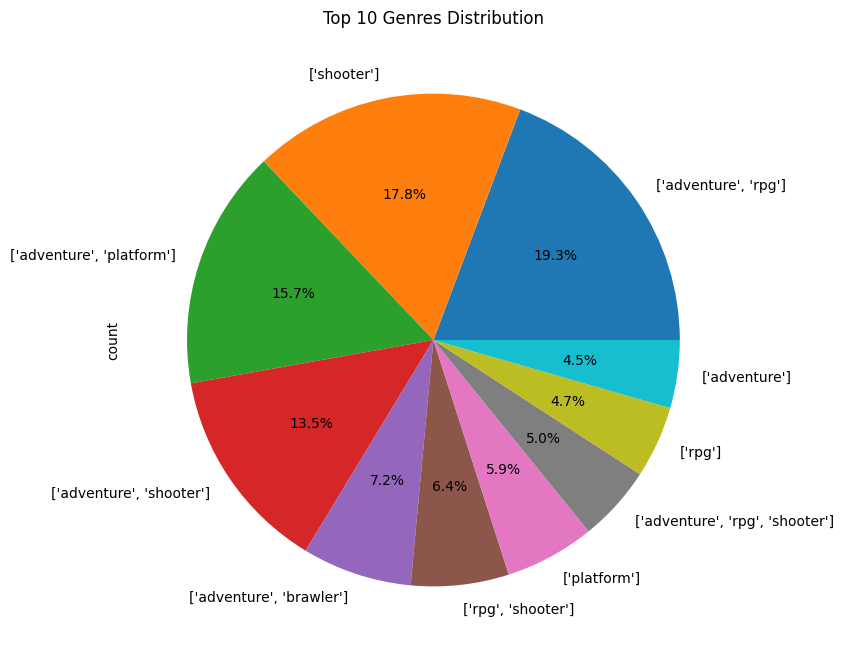

In [7]:
# Pie chart
plt.figure(figsize=(8, 8))
genre_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title('Top 10 Genres Distribution')
plt.show()

### ⏳ Which games have the highest backlog compared to wishlist?

In [8]:
# Assuming Backlogs and Wishlist are parsed
df['Backlogs'] = df['Backlogs'].apply(parse_number)
df['Wishlist'] = df['Wishlist'].apply(parse_number)
df['Backlog_Wishlist_Ratio'] = df['Backlogs'] / (df['Wishlist'] + 1)  # Avoid division by zero
top_ratio = df[['Title', 'Backlog_Wishlist_Ratio']].sort_values('Backlog_Wishlist_Ratio', ascending=False).head(10)
print(top_ratio)

                               Title  Backlog_Wishlist_Ratio
1003     Borderlands: The Pre-Sequel                7.949791
1004     Borderlands: The Pre-Sequel                7.949791
1005     Borderlands: The Pre-Sequel                7.949791
635                     Just Cause 3                6.410256
636                     Just Cause 3                6.410256
637                     Just Cause 3                6.410256
627   LEGO Batman 2: DC Super Heroes                6.172932
632   LEGO Batman 2: DC Super Heroes                6.172932
630   LEGO Batman 2: DC Super Heroes                6.172932
633   LEGO Batman 2: DC Super Heroes                6.172932


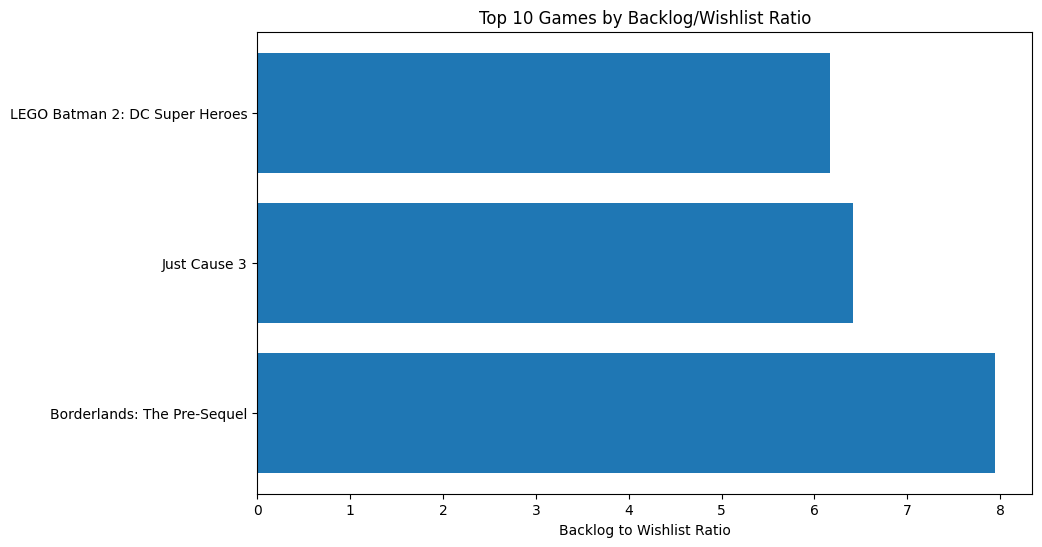

In [9]:
# Bar plot
plt.figure(figsize=(10, 6))
plt.barh(top_ratio['Title'], top_ratio['Backlog_Wishlist_Ratio'])
plt.xlabel('Backlog to Wishlist Ratio')
plt.title('Top 10 Games by Backlog/Wishlist Ratio')
plt.show()

### 🗓️ What is the game release trend across years?

In [10]:
# Release trend
release_trend = df['Release Date'].str.extract(r'(\d{4})')[0].value_counts().sort_index()
print(release_trend)

0
1980      2
1982      1
1985      2
1986      4
1987      2
1988      7
1989      8
1990      4
1991     20
1992      6
1993     25
1994     13
1995     15
1996     15
1997     20
1998     24
1999     25
2000     14
2001     37
2002     24
2003     31
2004     35
2005     65
2006     47
2007     58
2008     70
2009     61
2010    101
2011    118
2012    100
2013    135
2014     82
2015     69
2016     59
2017      9
2018      8
2019     12
2020      4
2022      3
2023      9
Name: count, dtype: int64


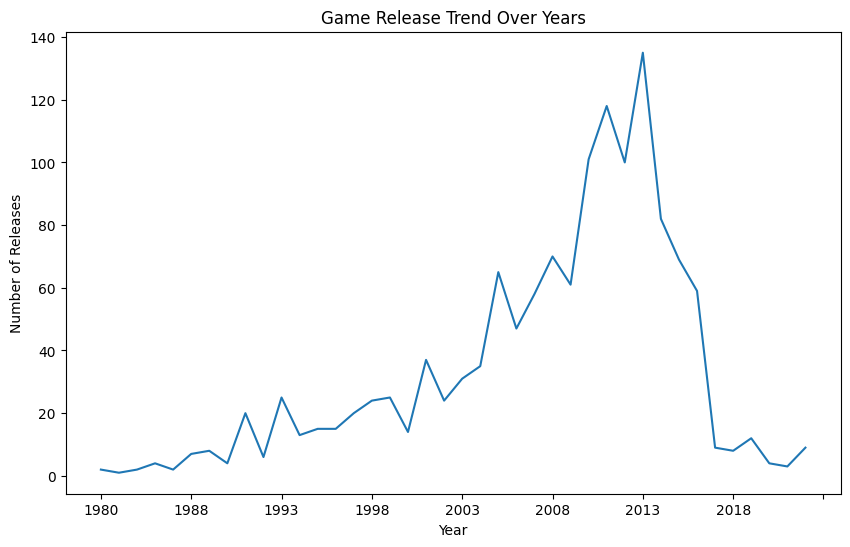

In [11]:
# Line plot
plt.figure(figsize=(10, 6))
release_trend.plot(kind='line')
plt.xlabel('Year')
plt.ylabel('Number of Releases')
plt.title('Game Release Trend Over Years')
plt.show()

### 🔎 What is the distribution of user ratings?

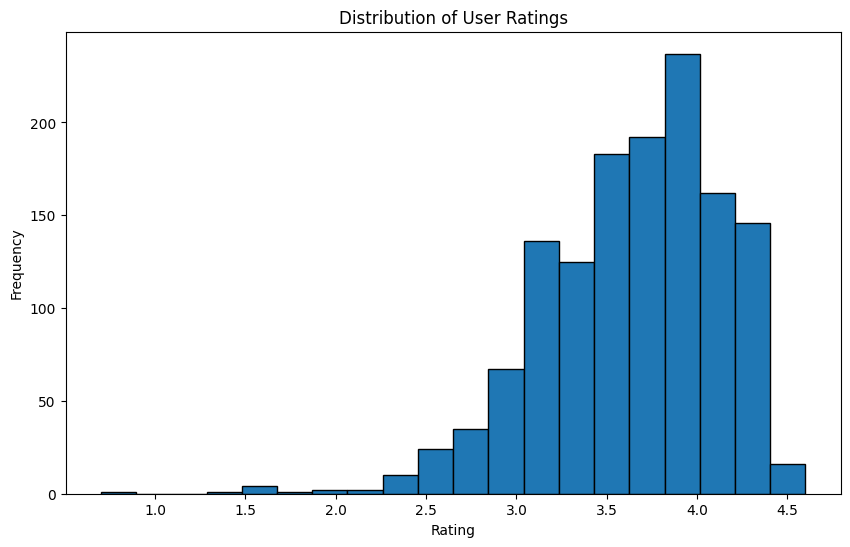

In [12]:
# Histogram of ratings
plt.figure(figsize=(10, 6))
plt.hist(df['Rating'].dropna(), bins=20, edgecolor='black')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.title('Distribution of User Ratings')
plt.show()

### 🧑 What are the top 10 most wishlisted games?

In [13]:
# Top wishlisted
top_wishlist = df[['Title', 'Wishlist']].sort_values('Wishlist', ascending=False).head(10)
print(top_wishlist)

          Title  Wishlist
10   Bloodborne    3300.0
704  Bloodborne    3300.0
315  Bloodborne    3300.0
700  God of War    2600.0
6    God of War    2600.0
311  God of War    2600.0
35    Bayonetta    2300.0
339   Bayonetta    2300.0
340   Bayonetta    2300.0
34    Bayonetta    2300.0


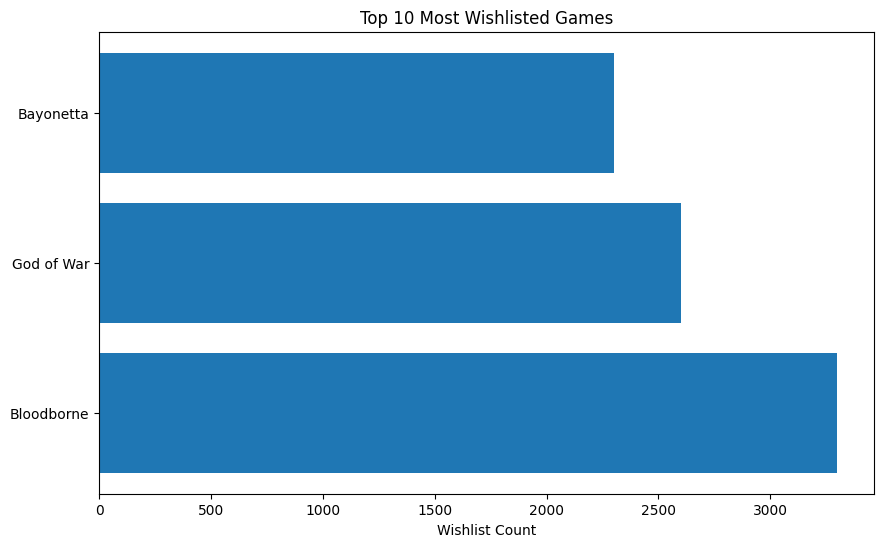

In [14]:
# Bar plot
plt.figure(figsize=(10, 6))
plt.barh(top_wishlist['Title'], top_wishlist['Wishlist'])
plt.xlabel('Wishlist Count')
plt.title('Top 10 Most Wishlisted Games')
plt.show()

### 🔬 What’s the average number of plays per genre?

In [15]:
# Average plays per genre
df['Plays'] = df['Plays'].apply(parse_number)
avg_plays_genre = df.groupby('Genres')['Plays'].mean().sort_values(ascending=False).head(10)
print(avg_plays_genre)

Genres
['adventure', 'simulator']                                               26536.000000
['adventure', 'platform', 'puzzle', 'shooter']                           20964.705882
['adventure', 'indie', 'platform', 'rpg', 'strategy']                    18000.000000
['simulator', 'sport']                                                   18000.000000
['indie', 'racing', 'sport']                                             17000.000000
['puzzle', 'real time strategy', 'simulator', 'strategy', 'tactical']    14000.000000
['adventure', 'brawler', 'shooter', 'strategy']                          14000.000000
['adventure', 'puzzle', 'shooter']                                       13000.000000
['adventure', 'puzzle', 'rpg']                                           12400.000000
['shooter', 'strategy']                                                  12259.400000
Name: Plays, dtype: float64


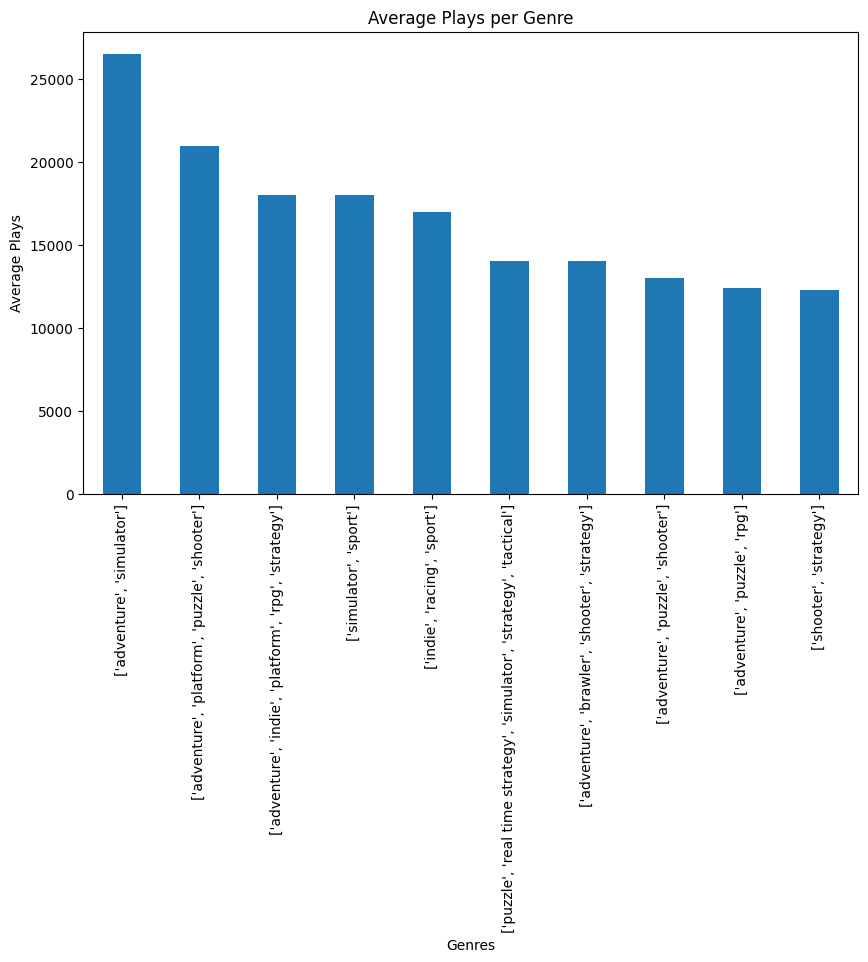

In [16]:
# Bar plot
plt.figure(figsize=(10, 6))
avg_plays_genre.plot(kind='bar')
plt.ylabel('Average Plays')
plt.title('Average Plays per Genre')
plt.show()

### 🏢 Which developer studios are the most productive and impactful?

In [17]:
# Productivity by number of games
productive_teams = df['Team'].value_counts().head(10)
print(productive_teams)

Team
['Capcom']                                        34
['Nintendo', 'Nintendo EAD']                      26
['Mojang Studios']                                24
['WB Games', "Traveller's Tales"]                 24
['Sonic Team', 'Sega']                            20
['FromSoftware', 'Bandai Namco Entertainment']    19
['Ubisoft Montreal', 'Ubisoft Entertainment']     18
['Rockstar North', 'Rockstar Games']              18
['Capcom', 'Capcom Production Studio 4']          17
['Square Enix']                                   16
Name: count, dtype: int64


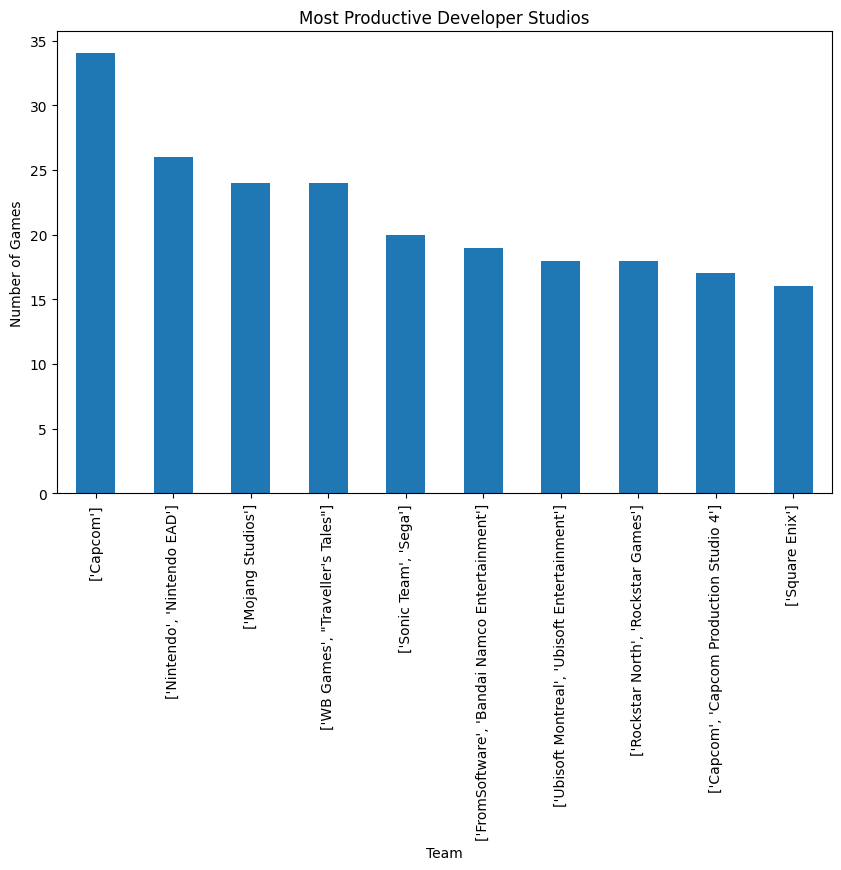

In [18]:
# Bar plot
plt.figure(figsize=(10, 6))
productive_teams.plot(kind='bar')
plt.ylabel('Number of Games')
plt.title('Most Productive Developer Studios')
plt.show()

## 💰 vgsales.csv (Sales Data Only)

### 🌍 Which region generates the most game sales?

In [19]:
# Total sales by region
regions = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']
total_sales_region = df[regions].sum()
print(total_sales_region)

NA_Sales       1727.22
EU_Sales       1036.93
JP_Sales        379.41
Other_Sales     336.42
dtype: float64


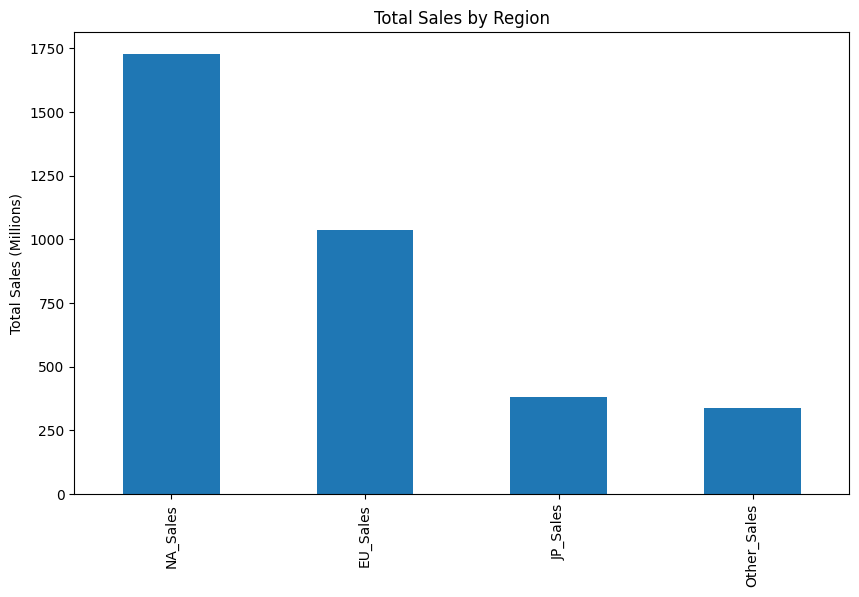

In [20]:
# Bar plot
plt.figure(figsize=(10, 6))
total_sales_region.plot(kind='bar')
plt.ylabel('Total Sales (Millions)')
plt.title('Total Sales by Region')
plt.show()

### 🕹️ What are the best-selling platforms?

In [21]:
# Best-selling platforms
platform_sales = df.groupby('Platform')['Global_Sales'].sum().sort_values(ascending=False).head(10)
print(platform_sales)

Platform
Wii     587.00
X360    560.34
PS3     551.33
PS2     229.51
PS4     186.73
DS      171.62
PS      169.74
NES     146.88
GB      129.21
N64     113.71
Name: Global_Sales, dtype: float64


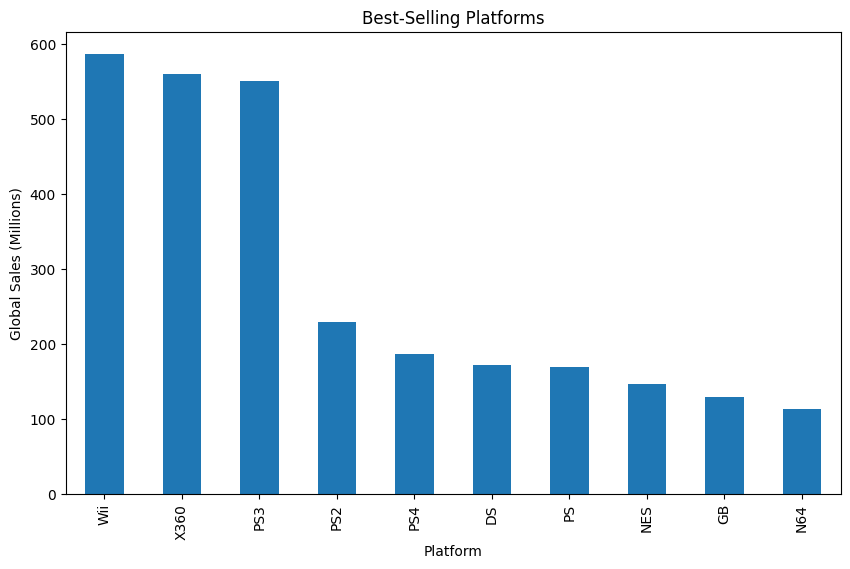

In [22]:
# Bar plot
plt.figure(figsize=(10, 6))
platform_sales.plot(kind='bar')
plt.ylabel('Global Sales (Millions)')
plt.title('Best-Selling Platforms')
plt.show()

### 📅 What’s the trend of game releases and sales over years?

In [23]:
# Sales trend over years
sales_trend = df.groupby('Year')['Global_Sales'].sum()
print(sales_trend)

Year
1981.0      1.65
1982.0      7.81
1984.0      1.22
1985.0     40.24
1986.0     14.25
1987.0      5.19
1988.0     79.06
1989.0     91.63
1990.0     23.18
1991.0     24.63
1992.0     40.16
1993.0     10.90
1994.0     44.56
1995.0     26.70
1996.0     89.38
1997.0     60.32
1998.0     76.50
1999.0     52.17
2000.0     26.49
2001.0     79.47
2002.0     80.09
2003.0     52.35
2004.0    100.83
2005.0    100.84
2006.0    376.27
2007.0    175.65
2008.0    280.43
2009.0    191.18
2010.0    232.91
2011.0    240.59
2012.0    190.95
2013.0    306.41
2014.0    210.26
2015.0    110.06
2016.0     35.77
Name: Global_Sales, dtype: float64


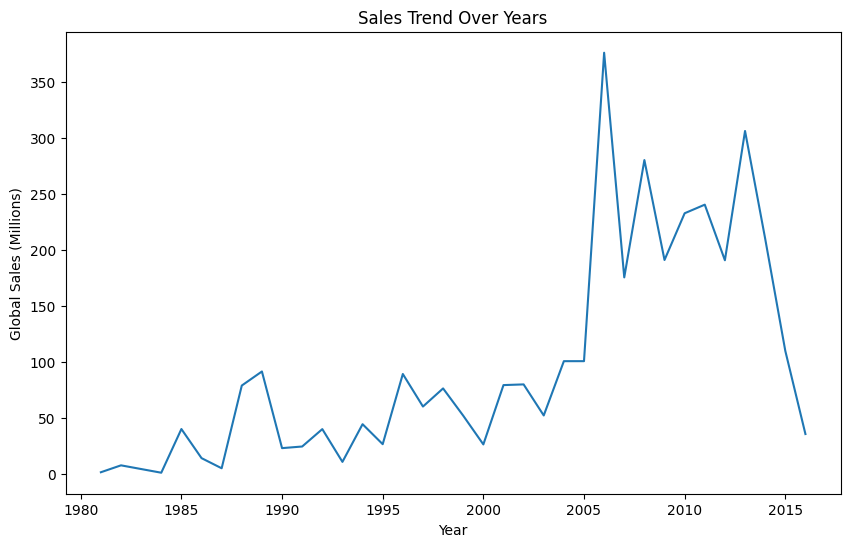

In [24]:
# Line plot
plt.figure(figsize=(10, 6))
sales_trend.plot(kind='line')
plt.xlabel('Year')
plt.ylabel('Global Sales (Millions)')
plt.title('Sales Trend Over Years')
plt.show()

### 🏢 Who are the top publishers by sales?

In [25]:
# Top publishers
publisher_sales = df.groupby('Publisher')['Global_Sales'].sum().sort_values(ascending=False).head(10)
print(publisher_sales)

Publisher
Nintendo                                  1330.84
Take-Two Interactive                       354.39
Activision                                 282.63
Sony Computer Entertainment                221.39
Electronic Arts                            159.61
Bethesda Softworks                         141.90
Ubisoft                                    132.70
Microsoft Game Studios                     119.81
Warner Bros. Interactive Entertainment     111.70
Capcom                                      90.58
Name: Global_Sales, dtype: float64


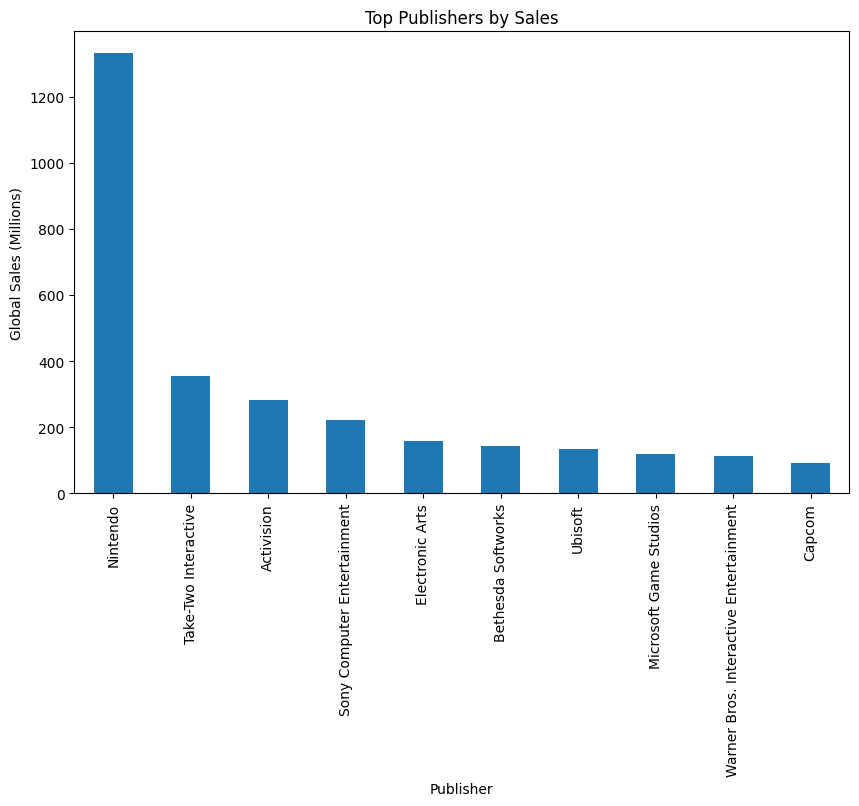

In [26]:
# Bar plot
plt.figure(figsize=(10, 6))
publisher_sales.plot(kind='bar')
plt.ylabel('Global Sales (Millions)')
plt.title('Top Publishers by Sales')
plt.show()

### 🔝 Which games are the top 10 best-sellers globally?

In [27]:
# Top 10 best-sellers
top_sellers = df[['Title', 'Global_Sales']].sort_values('Global_Sales', ascending=False).head(10)
print(top_sellers)

                  Title  Global_Sales
812          Wii Sports         82.74
138          Wii Sports         82.74
411          Wii Sports         82.74
62    Super Mario Bros.         40.24
813      Mario Kart Wii         35.82
139      Mario Kart Wii         35.82
412      Mario Kart Wii         35.82
1062             Tetris         30.26
485              Tetris         30.26
233              Tetris         30.26


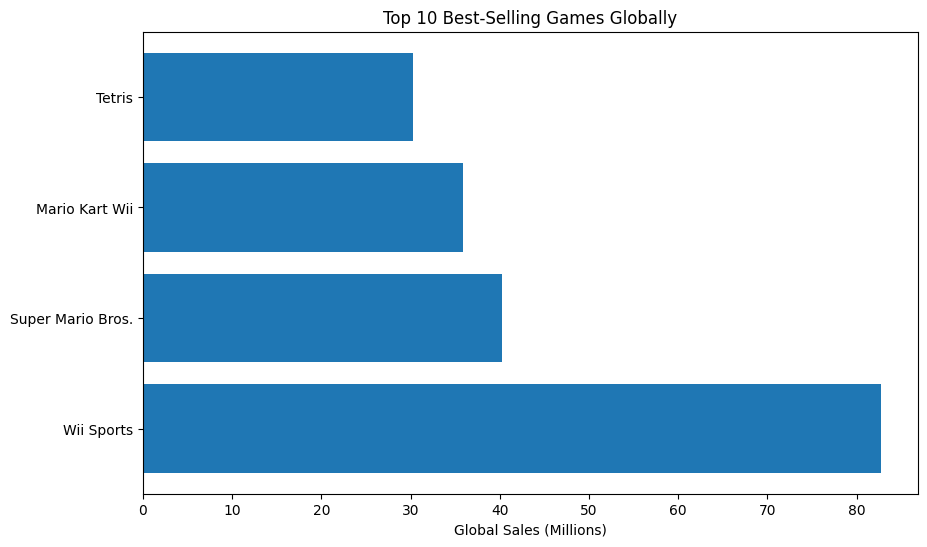

In [28]:
# Bar plot
plt.figure(figsize=(10, 6))
plt.barh(top_sellers['Title'], top_sellers['Global_Sales'])
plt.xlabel('Global Sales (Millions)')
plt.title('Top 10 Best-Selling Games Globally')
plt.show()

### 🧭 How do regional sales compare for specific platforms?

In [29]:
# Regional sales for top platform, e.g., PS2
platform_data = df[df['Platform'] == 'PS2'][regions].sum()
print(platform_data)

NA_Sales       117.93
EU_Sales        48.80
JP_Sales        22.34
Other_Sales     40.50
dtype: float64


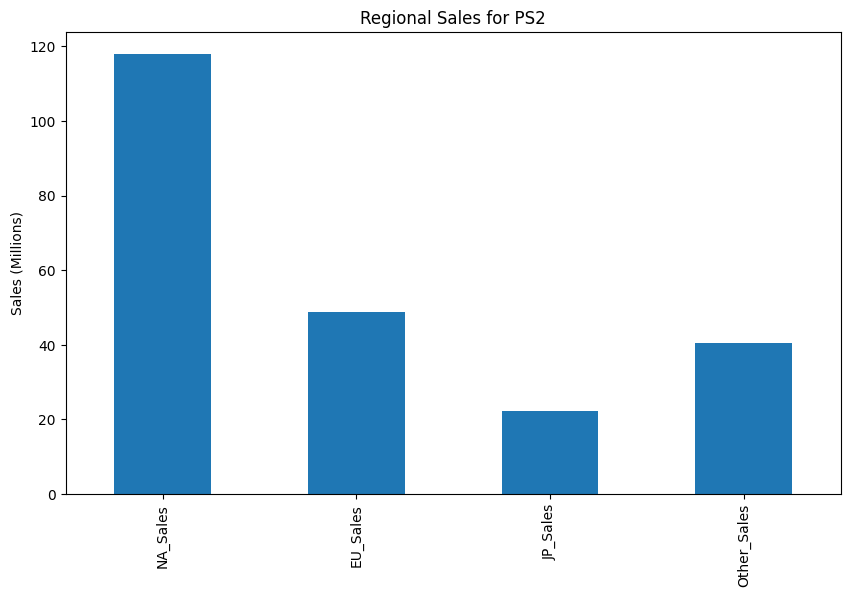

In [30]:
# Bar plot
plt.figure(figsize=(10, 6))
platform_data.plot(kind='bar')
plt.ylabel('Sales (Millions)')
plt.title('Regional Sales for PS2')
plt.show()

### 📈 How has the market evolved by platform over time?

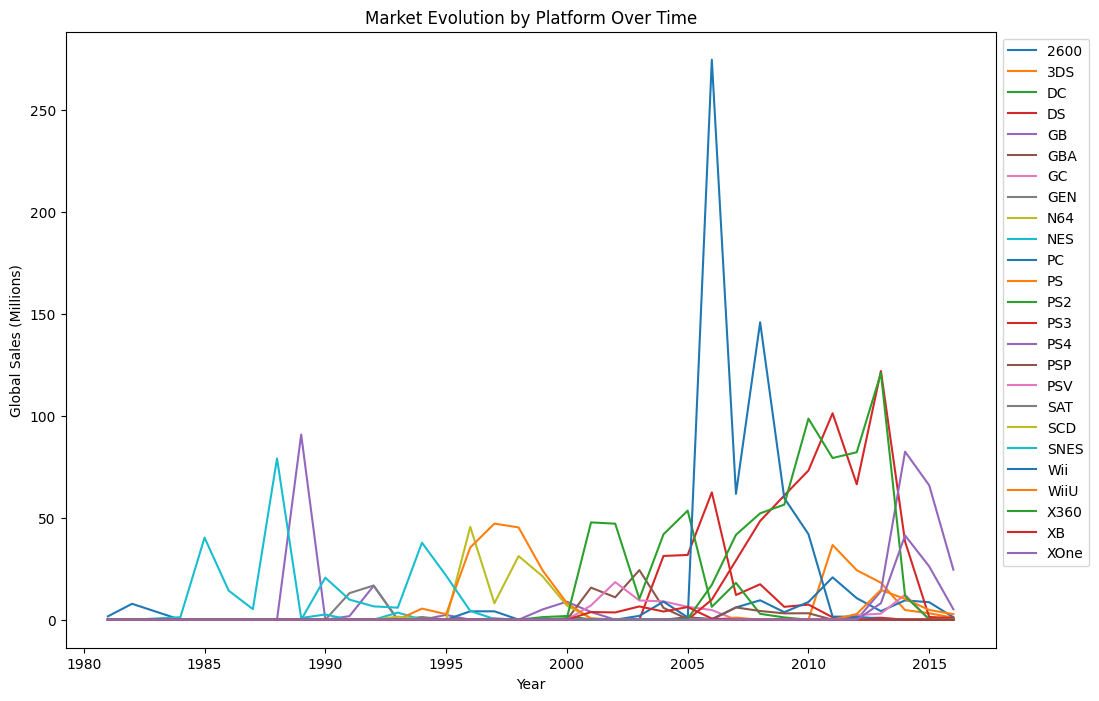

In [31]:
# Platform evolution
platform_year = df.groupby(['Year', 'Platform'])['Global_Sales'].sum().unstack().fillna(0)
platform_year.plot(figsize=(12, 8))
plt.xlabel('Year')
plt.ylabel('Global Sales (Millions)')
plt.title('Market Evolution by Platform Over Time')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

### 📍 What are the regional genre preferences?

In [32]:
# Genre preferences by region
genre_region = df.groupby('Genres')[regions].sum().idxmax(axis=1)
print(genre_region.head(10))

Genres
['adventure', 'arcade', 'platform', 'shooter']           NA_Sales
['adventure', 'arcade', 'platform']                      NA_Sales
['adventure', 'arcade', 'racing', 'shooter']             NA_Sales
['adventure', 'brawler', 'platform', 'rpg']              NA_Sales
['adventure', 'brawler', 'platform']                     NA_Sales
['adventure', 'brawler', 'puzzle', 'shooter']            JP_Sales
['adventure', 'brawler', 'puzzle']                       NA_Sales
['adventure', 'brawler', 'rpg', 'simulator', 'sport']    JP_Sales
['adventure', 'brawler', 'rpg', 'simulator']             NA_Sales
['adventure', 'brawler', 'rpg', 'strategy']              JP_Sales
dtype: object


### 🔄 What’s the yearly sales change per region?

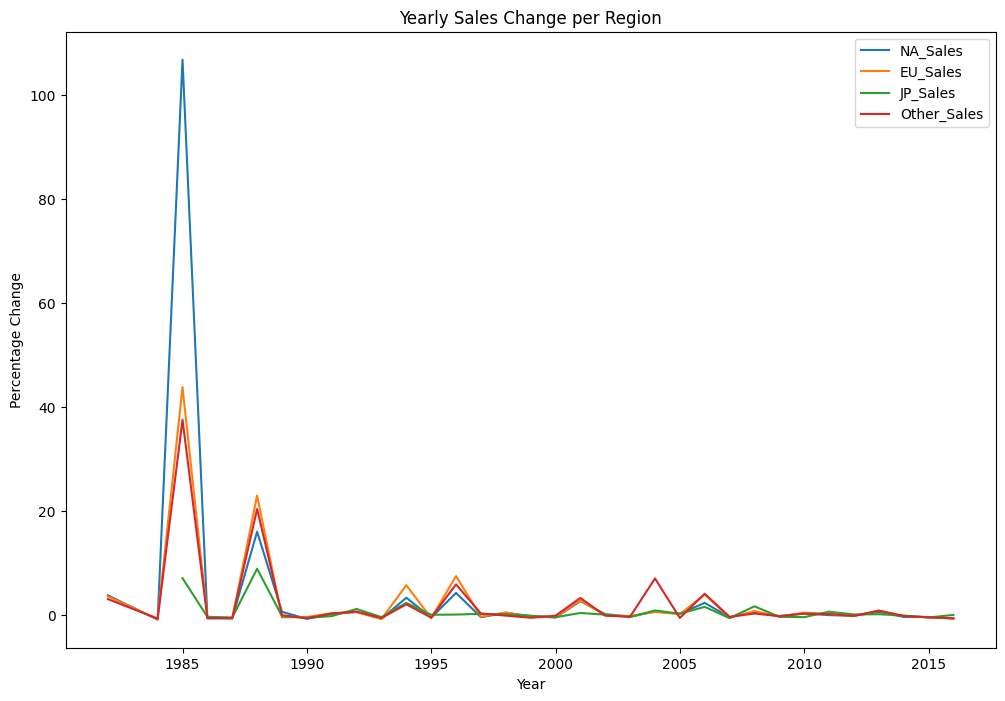

In [33]:
# Yearly change
yearly_sales = df.groupby('Year')[regions].sum().pct_change()
yearly_sales.plot(figsize=(12, 8))
plt.xlabel('Year')
plt.ylabel('Percentage Change')
plt.title('Yearly Sales Change per Region')
plt.legend()
plt.show()

### 🧮 What is the average sales per publisher?

In [34]:
# Average sales per publisher
avg_sales_publisher = df.groupby('Publisher')['Global_Sales'].mean().sort_values(ascending=False).head(10)
print(avg_sales_publisher)

Publisher
Nintendo                              8.017108
Microsoft Game Studios                4.278929
Take-Two Interactive                  4.073448
Activision                            3.670519
Sony Computer Entertainment           3.570806
Virgin Interactive                    3.500000
Sony Computer Entertainment Europe    2.573846
Bethesda Softworks                    2.489474
Arena Entertainment                   2.360000
SquareSoft                            1.991111
Name: Global_Sales, dtype: float64


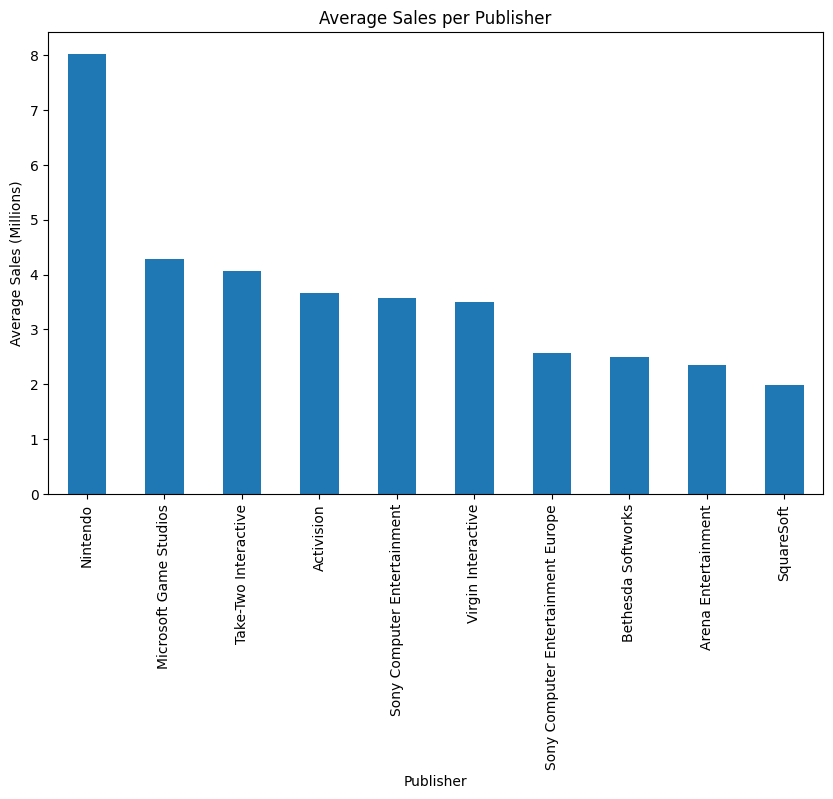

In [35]:
# Bar plot
plt.figure(figsize=(10, 6))
avg_sales_publisher.plot(kind='bar')
plt.ylabel('Average Sales (Millions)')
plt.title('Average Sales per Publisher')
plt.show()

### 🏆 What are the top 5 best-selling games per platform?

In [36]:
# Top 5 per platform
top_per_platform = df.groupby('Platform').apply(lambda x: x.nlargest(5, 'Global_Sales')[['Title', 'Global_Sales']])
print(top_per_platform.head(20))  # Sample

                                                  Title  Global_Sales
Platform                                                             
2600     554                                    Pac-Man          7.81
         1277                               Ms. Pac-Man          1.65
3DS      498                               Mario Kart 7         12.21
         855                        Super Mario 3D Land         10.79
         574                    New Super Mario Bros. 2          9.82
         932                  Animal Crossing: New Leaf          9.09
         1081                            Tomodachi Life          5.15
DC       1026                                Crazy Taxi          1.81
         1041                                   Shenmue          1.18
         933                          Sonic Adventure 2          0.12
         1191  Marvel vs. Capcom: Clash of Super Heroes          0.10
DS       157                      New Super Mario Bros.         30.01
         430        

C:\Users\user\AppData\Local\Temp\ipykernel_18248\2112416211.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_per_platform = df.groupby('Platform').apply(lambda x: x.nlargest(5, 'Global_Sales')[['Title', 'Global_Sales']])


## 🔁 Merged Dataset (Sales + Engagement + Ratings)

### 🎮 Which game genres generate the most global sales?

In [37]:
# Genres by sales
genre_sales = df.groupby('Genres')['Global_Sales'].sum().sort_values(ascending=False).head(10)
print(genre_sales)

Genres
['adventure', 'platform']     528.82
['shooter']                   377.03
['adventure', 'rpg']          309.41
['adventure', 'shooter']      289.24
['simulator', 'sport']        248.22
['racing']                    185.13
['platform']                  155.70
['adventure', 'simulator']    100.07
['rpg', 'shooter']             95.98
['adventure', 'brawler']       87.55
Name: Global_Sales, dtype: float64


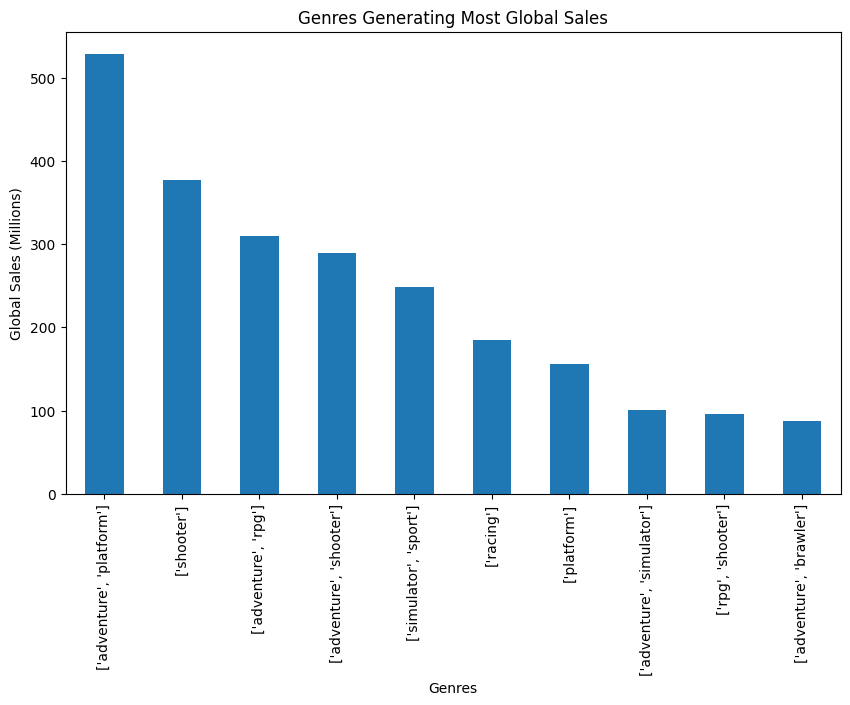

In [38]:
# Bar plot
plt.figure(figsize=(10, 6))
genre_sales.plot(kind='bar')
plt.ylabel('Global Sales (Millions)')
plt.title('Genres Generating Most Global Sales')
plt.show()

### 🎯 How does user rating affect global sales?

In [39]:
# Correlation
correlation = df[['Rating', 'Global_Sales']].corr()
print(correlation)

                Rating  Global_Sales
Rating        1.000000      0.066589
Global_Sales  0.066589      1.000000


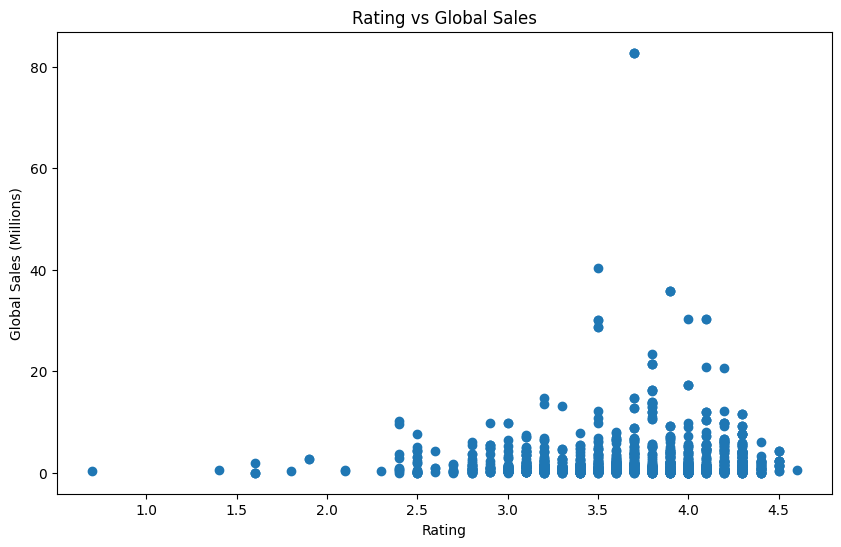

In [40]:
# Scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(df['Rating'], df['Global_Sales'])
plt.xlabel('Rating')
plt.ylabel('Global Sales (Millions)')
plt.title('Rating vs Global Sales')
plt.show()

### 🕹️ Which platforms have the most games with high ratings (e.g., above 4)?

In [41]:
# High-rated games per platform
high_rated = df[df['Rating'] > 4].groupby('Platform').size().sort_values(ascending=False).head(10)
print(high_rated)

Platform
PS3     41
PS2     37
PC      35
X360    30
PS4     22
PS      21
DS      20
SNES    19
GC      16
Wii     12
dtype: int64


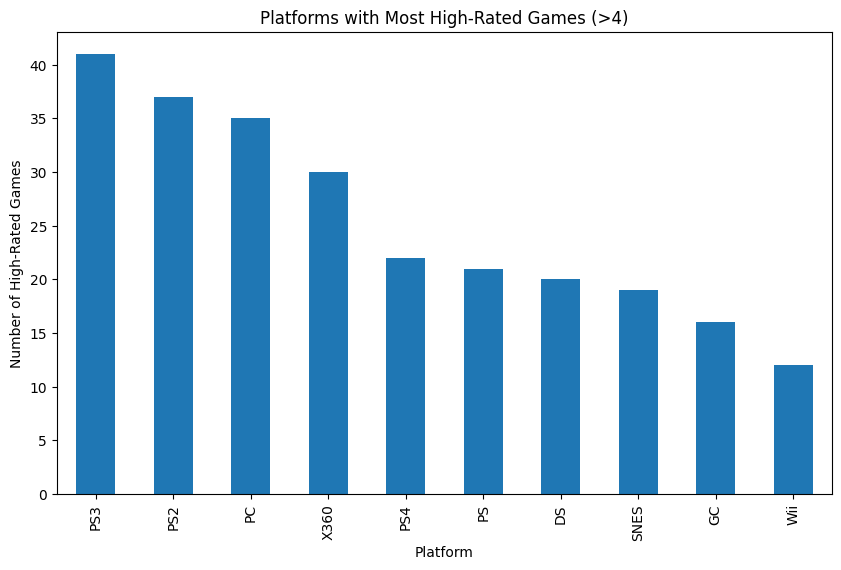

In [42]:
# Bar plot
plt.figure(figsize=(10, 6))
high_rated.plot(kind='bar')
plt.ylabel('Number of High-Rated Games')
plt.title('Platforms with Most High-Rated Games (>4)')
plt.show()

### 📈 What’s the trend of releases and sales over time?

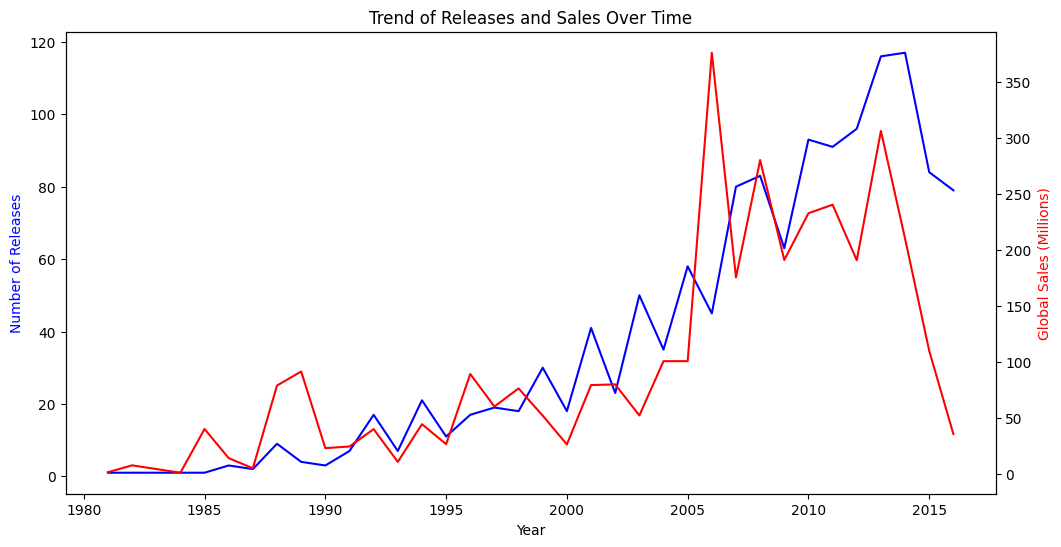

In [43]:
# Combined trend
releases = df['Year'].value_counts().sort_index()
sales = df.groupby('Year')['Global_Sales'].sum()
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(releases.index, releases.values, 'b-', label='Releases')
ax2 = ax1.twinx()
ax2.plot(sales.index, sales.values, 'r-', label='Sales')
ax1.set_xlabel('Year')
ax1.set_ylabel('Number of Releases', color='b')
ax2.set_ylabel('Global Sales (Millions)', color='r')
plt.title('Trend of Releases and Sales Over Time')
plt.show()

### 🧍 Do highly wishlisted games lead to more sales?

In [44]:
# Correlation between Wishlist and Sales
wishlist_sales_corr = df[['Wishlist', 'Global_Sales']].corr()
print(wishlist_sales_corr)

              Wishlist  Global_Sales
Wishlist      1.000000     -0.059552
Global_Sales -0.059552      1.000000


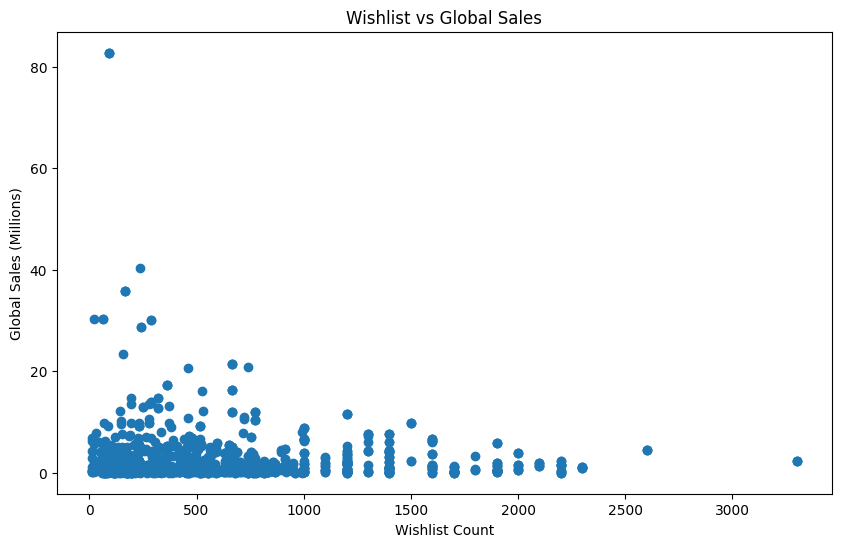

In [45]:
# Scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(df['Wishlist'], df['Global_Sales'])
plt.xlabel('Wishlist Count')
plt.ylabel('Global Sales (Millions)')
plt.title('Wishlist vs Global Sales')
plt.show()

### 🎮 Which genres have the highest engagement but lowest sales?

In [46]:
# Engagement as Plays + Wishlist, compare to sales
df['Engagement'] = df['Plays'] + df['Wishlist']
genre_engagement = df.groupby('Genres')['Engagement'].mean()
genre_sales_mean = df.groupby('Genres')['Global_Sales'].mean()
comparison = pd.DataFrame({'Engagement': genre_engagement, 'Sales': genre_sales_mean})
comparison['Ratio'] = comparison['Engagement'] / (comparison['Sales'] + 1)
top_ratio = comparison.sort_values('Ratio', ascending=False).head(10)
print(top_ratio)

                                                      Engagement     Sales  \
Genres                                                                       
['adventure', 'indie', 'platform', 'rpg', 'stra...  18593.000000  0.210000   
['indie', 'racing', 'sport']                        17113.000000  0.123333   
['puzzle', 'real time strategy', 'simulator', '...  14082.000000  0.420000   
['adventure', 'point-and-click', 'visual novel']    11610.500000  0.275000   
['adventure', 'indie', 'platform']                   9700.000000  0.106667   
['adventure', 'indie', 'simulator']                  8525.000000  0.010000   
['adventure', 'brawler', 'shooter', 'strategy']     16000.000000  0.985000   
['adventure', 'platform', 'puzzle', 'shooter']      21810.235294  2.143529   
['brawler', 'shooter']                              14017.714286  1.112857   
['adventure', 'point-and-click']                     7677.625000  0.201250   

                                                           Rati

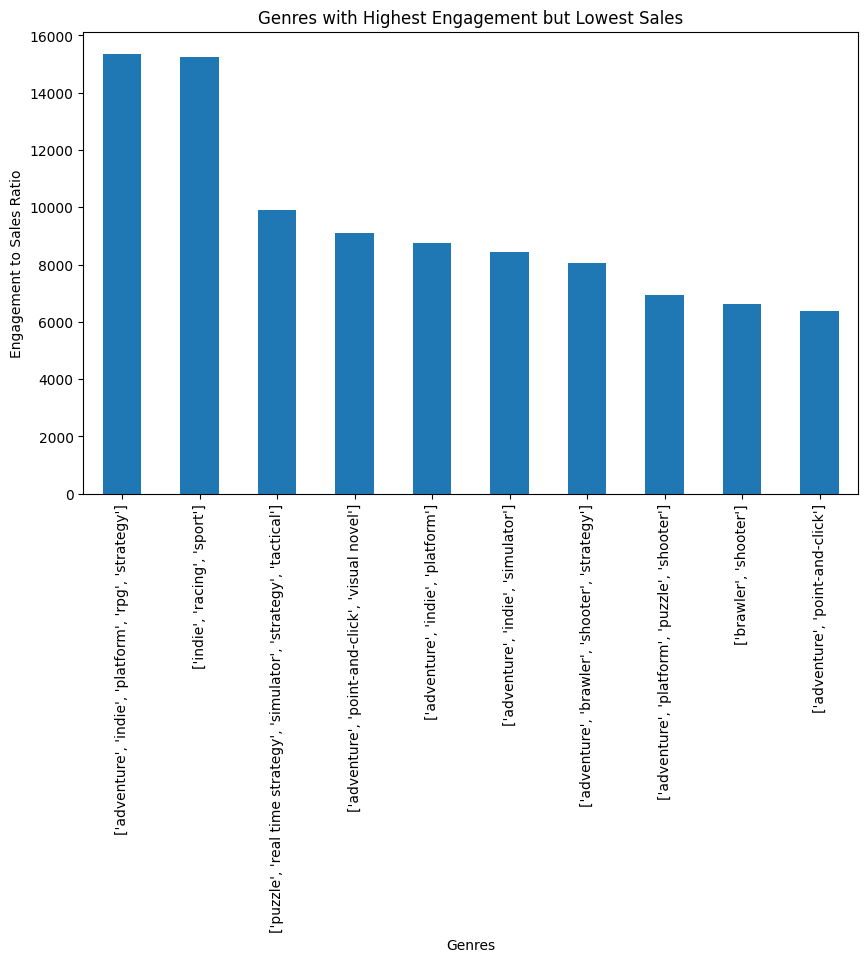

In [47]:
# Bar plot for ratio
plt.figure(figsize=(10, 6))
top_ratio['Ratio'].plot(kind='bar')
plt.ylabel('Engagement to Sales Ratio')
plt.title('Genres with Highest Engagement but Lowest Sales')
plt.show()

### 🧠 Do highly listed games (wishlist/backlogs) correlate with better ratings?

In [48]:
# Correlation
listing_corr = df[['Wishlist', 'Backlogs', 'Rating']].corr()
print(listing_corr)

          Wishlist  Backlogs    Rating
Wishlist  1.000000  0.835835  0.538374
Backlogs  0.835835  1.000000  0.481165
Rating    0.538374  0.481165  1.000000


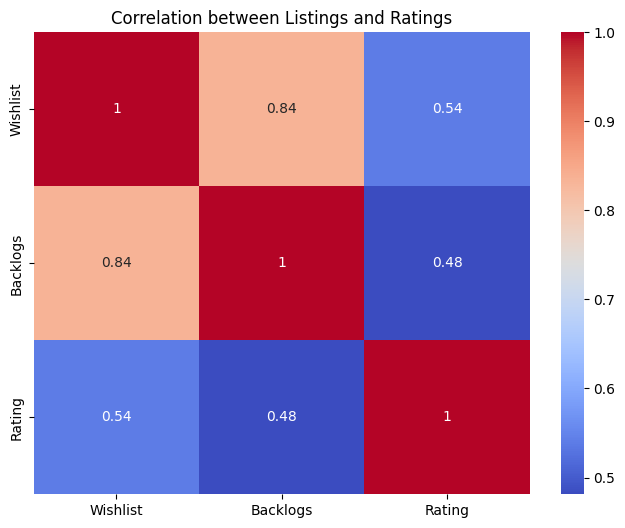

In [49]:
# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(listing_corr, annot=True, cmap='coolwarm')
plt.title('Correlation between Listings and Ratings')
plt.show()

### 🏷️ How does user engagement differ across genres?

In [50]:
# Engagement by genre
engagement_genre = df.groupby('Genres')['Engagement'].mean().sort_values(ascending=False).head(10)
print(engagement_genre)

Genres
['adventure', 'simulator']                                               26727.320000
['adventure', 'platform', 'puzzle', 'shooter']                           21810.235294
['adventure', 'indie', 'platform', 'rpg', 'strategy']                    18593.000000
['simulator', 'sport']                                                   18093.000000
['indie', 'racing', 'sport']                                             17113.000000
['adventure', 'brawler', 'shooter', 'strategy']                          16000.000000
['puzzle', 'real time strategy', 'simulator', 'strategy', 'tactical']    14082.000000
['brawler', 'shooter']                                                   14017.714286
['adventure', 'puzzle', 'shooter']                                       13892.000000
['adventure', 'tactical']                                                13600.000000
Name: Engagement, dtype: float64


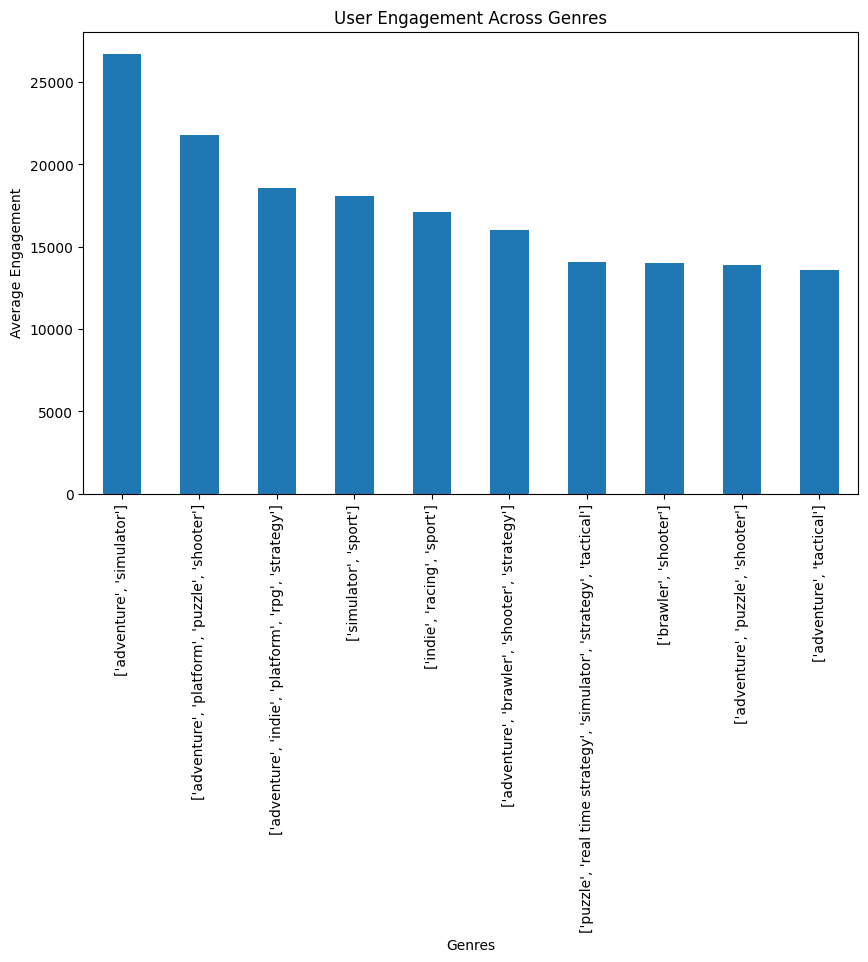

In [51]:
# Bar plot
plt.figure(figsize=(10, 6))
engagement_genre.plot(kind='bar')
plt.ylabel('Average Engagement')
plt.title('User Engagement Across Genres')
plt.show()

### 🎉 What are the top-performing combinations of Genre + Platform?

In [52]:
# Top combinations by sales
combo_sales = df.groupby(['Genres', 'Platform'])['Global_Sales'].sum().sort_values(ascending=False).head(10)
print(combo_sales)

Genres                     Platform
['simulator', 'sport']     Wii         248.22
['shooter']                X360        163.37
['adventure', 'platform']  Wii         125.98
['racing']                 Wii         107.94
['adventure', 'platform']  DS          100.43
['adventure', 'shooter']   PS3          99.09
['shooter']                PS3          93.60
['adventure', 'shooter']   X360         70.79
['arcade', 'puzzle']       GB           60.52
['adventure', 'platform']  SNES         59.80
Name: Global_Sales, dtype: float64


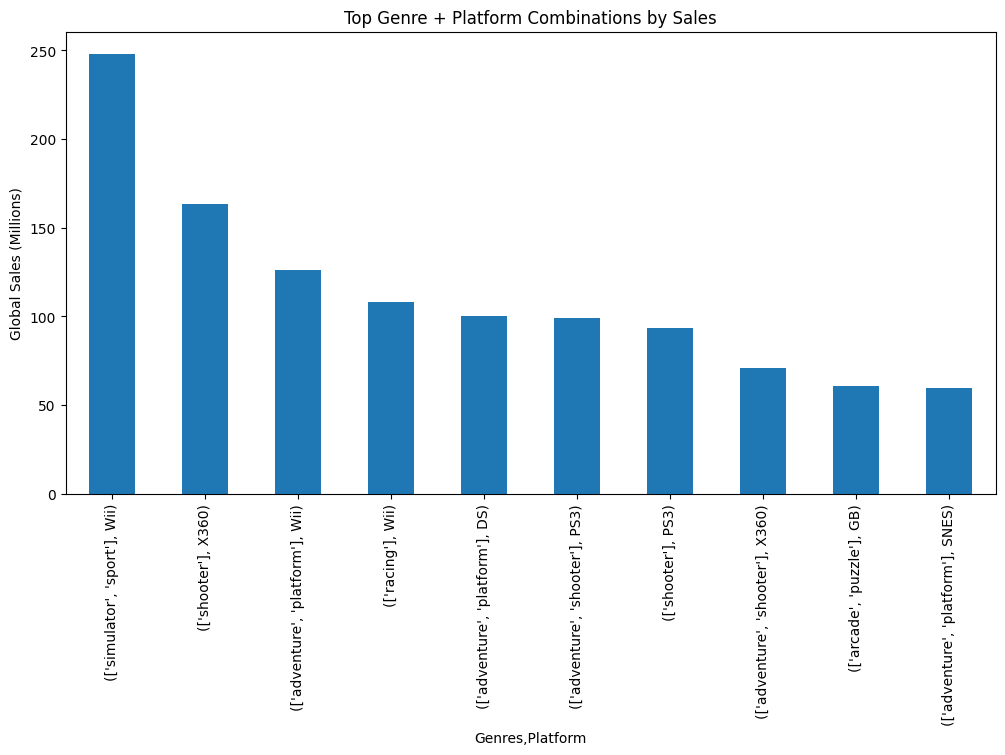

In [53]:
# Bar plot
plt.figure(figsize=(12, 6))
combo_sales.plot(kind='bar')
plt.ylabel('Global Sales (Millions)')
plt.title('Top Genre + Platform Combinations by Sales')
plt.show()

### 🌐 What does a regional sales heatmap by genre reveal?

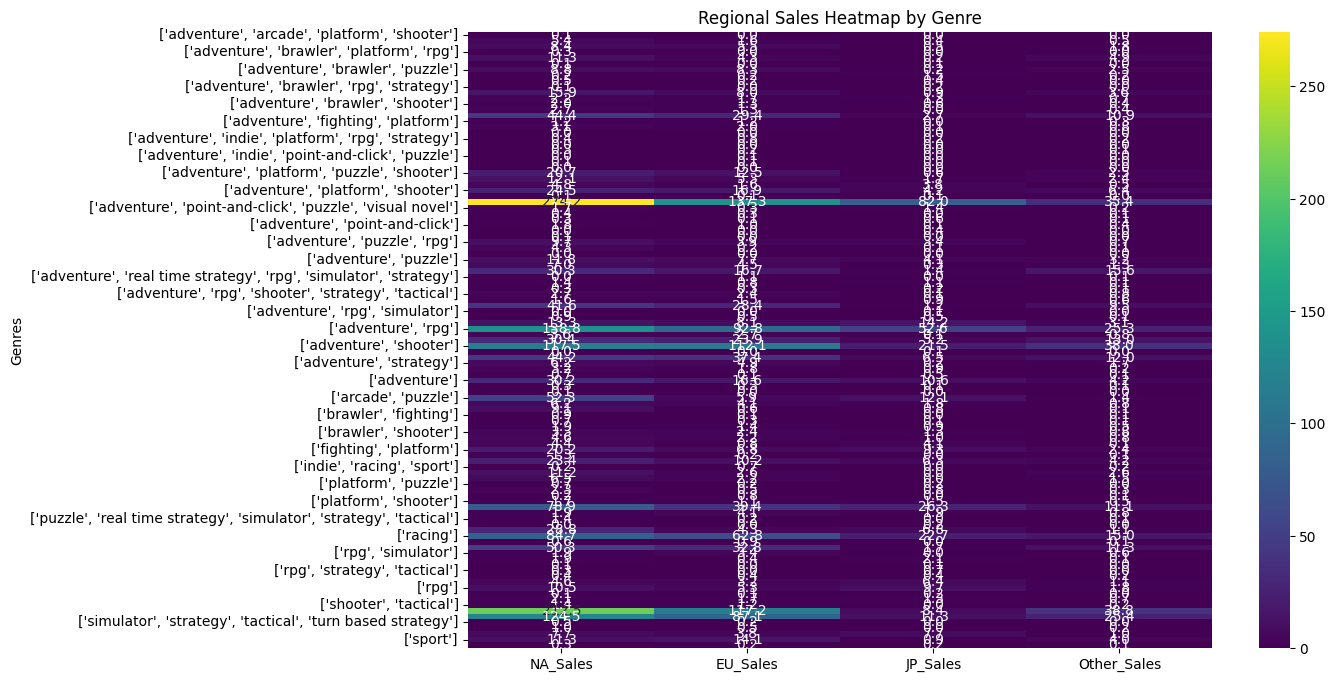

In [54]:
# Heatmap of regional sales by genre
genre_region_sales = df.groupby('Genres')[regions].sum()
plt.figure(figsize=(12, 8))
sns.heatmap(genre_region_sales, annot=True, fmt='.1f', cmap='viridis')
plt.title('Regional Sales Heatmap by Genre')
plt.show()